In [1]:
# ---- Reproducibility
import random
import torch

seed = 1234
random.seed(seed)
torch.manual_seed(seed) 


In [2]:


# ---- Parameters
n, p = 50, 40
noise_std = 0.1

# (Optional) choose device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ---- Data generation (PyTorch)
# Use float64 to mirror NumPy defaults
u = torch.rand(n, dtype=torch.float64, device=device)          # length n
v = torch.rand(p, dtype=torch.float64, device=device)          # length p

# Rank-1 matrix via outer product
rank_1_matrix = torch.outer(u, v)                              # (n, p)

# Homoscedastic Gaussian noise
noise = noise_std * torch.randn(n, p, dtype=torch.float64, device=device)

noisy_matrix = rank_1_matrix + noise

# ---- Print (move to CPU for readability if needed)
print("Rank-1 Matrix (Outer Product):")
print(rank_1_matrix.cpu().numpy())

print("\nNoisy Matrix (with Homoscedastic Noise):")
print(noisy_matrix.cpu().numpy())


Rank-1 Matrix (Outer Product):
[[0.0369924  0.12349849 0.01266485 ... 0.20919041 0.20178125 0.15269329]
 [0.01256629 0.04195233 0.00430224 ... 0.0710618  0.06854491 0.05186978]
 [0.07442166 0.24845541 0.02547927 ... 0.42085123 0.40594542 0.3071898 ]
 ...
 [0.13003676 0.43412546 0.04451985 ... 0.73535219 0.70930731 0.53675188]
 [0.02568535 0.08575008 0.00879373 ... 0.14524951 0.14010503 0.10602124]
 [0.01213768 0.04052142 0.0041555  ... 0.06863803 0.06620699 0.05010061]]

Noisy Matrix (with Homoscedastic Noise):
[[ 0.14788041  0.16955928  0.1824038  ...  0.06284919  0.26615598
   0.04153663]
 [-0.07975735  0.07738678 -0.06536086 ...  0.08710195  0.01799688
   0.10035783]
 [ 0.15693369  0.13496091 -0.12057474 ...  0.40187727  0.53974668
   0.3314774 ]
 ...
 [ 0.16086152  0.64130937  0.12866035 ...  0.67670073  0.59595961
   0.57849158]
 [-0.06675871 -0.03323521 -0.03429034 ...  0.1487228   0.2078188
   0.18898802]
 [-0.14480705  0.07884231  0.03359961 ... -0.16932926  0.1779711
   0.1486

In [3]:
import sys
import os
import matplotlib.pyplot as plt
from cebmf_torch import cEBMF

In [4]:
mycebmf=  cEBMF(data= noisy_matrix, prior_F="exp",
                prior_L="exp") 

 

In [5]:
mycebmf.initialise_factors()
print(mycebmf.L[:,1])
print(mycebmf.F[:,1])

tensor([ 0.0080, -0.1905,  0.2605, -0.2120,  0.2116,  0.1896, -0.2458, -0.2640,
         0.1057,  0.1225,  0.0676,  0.0620, -0.0016,  0.1750,  0.1087, -0.0761,
         0.1078, -0.4832,  0.0641,  0.1960, -0.2287, -0.0704, -0.2441,  0.0377,
        -0.2611, -0.1291,  0.3901, -0.0387, -0.1331, -0.2875, -0.2095,  0.1439,
        -0.0307, -0.0648,  0.0598, -0.0430,  0.1896,  0.1109,  0.0643, -0.0023,
        -0.0328, -0.2137,  0.0720,  0.0039, -0.1591, -0.2714, -0.0136,  0.1367,
         0.0542,  0.2452], dtype=torch.float64)
tensor([ 0.0610,  0.0381, -0.0373,  0.1844, -0.0388, -0.1764,  0.0488, -0.3281,
        -0.0793,  0.0009,  0.2299,  0.1970,  0.0735, -0.2066,  0.0725, -0.2878,
        -0.0727,  0.3067, -0.2505,  0.0539,  0.1928,  0.0201, -0.0158,  0.1157,
         0.1509,  0.0815,  0.0377,  0.1380,  0.1188, -0.1703, -0.0225, -0.0766,
        -0.2759,  0.2154,  0.2396, -0.1764, -0.0045, -0.1609,  0.1603,  0.0669],
       dtype=torch.float64)


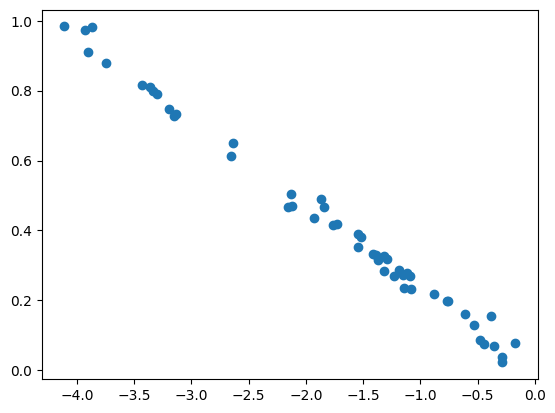

In [6]:
plt.scatter( mycebmf.L[:,0],u)

In [7]:
mycebmf.iter_once()
mycebmf._update_fitted_value()
import numpy as np
K=0
mycebmf.Y_fit 

tensor([[0.1201, 0.2833, 0.0337,  ..., 0.3295, 0.3183, 0.1981],
        [0.0254, 0.1173, 0.0138,  ..., 0.1382, 0.1498, 0.1349],
        [0.0733, 0.2633, 0.0185,  ..., 0.3522, 0.4294, 0.3199],
        ...,
        [0.0783, 0.1874, 0.0190,  ..., 0.2375, 0.2426, 0.1480],
        [0.0334, 0.1942, 0.0212,  ..., 0.2686, 0.2842, 0.2521],
        [0.1107, 0.5480, 0.0541,  ..., 0.6469, 0.7769, 0.6881]],
       dtype=torch.float64)

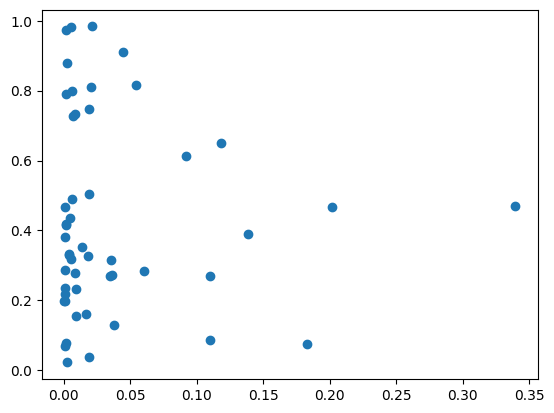

In [8]:
plt.scatter( mycebmf.L[:,0],u)

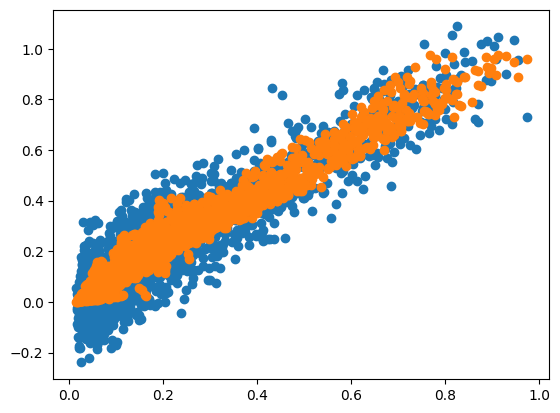

In [9]:
mycebmf.iter_once()  
mycebmf._update_fitted_value()
plt.scatter(mycebmf.Y_fit, noisy_matrix)
 
plt.scatter(mycebmf.Y_fit, rank_1_matrix)

In [10]:
mycebmf.fit()

CEBMFResult(L=tensor([[0.1221],
        [0.0199],
        [0.2443],
        [0.1994],
        [0.1749],
        [0.1393],
        [0.0860],
        [0.1294],
        [0.1233],
        [0.4428],
        [0.3812],
        [0.0316],
        [0.3557],
        [0.3008],
        [0.1302],
        [0.1575],
        [0.1555],
        [0.0855],
        [0.3626],
        [0.2990],
        [0.1340],
        [0.1598],
        [0.1719],
        [0.1749],
        [0.0399],
        [0.0322],
        [0.2403],
        [0.1458],
        [0.4253],
        [0.2082],
        [0.4462],
        [0.1494],
        [0.3780],
        [0.2189],
        [0.1488],
        [0.4388],
        [0.0540],
        [0.0598],
        [0.2410],
        [0.1264],
        [0.2116],
        [0.1959],
        [0.4664],
        [0.0430],
        [0.3740],
        [0.0991],
        [0.3571],
        [0.3890],
        [0.0689],
        [0.0499]], dtype=torch.float64), F=tensor([[0.3037],
        [1.2394],
        [0.0693],
       

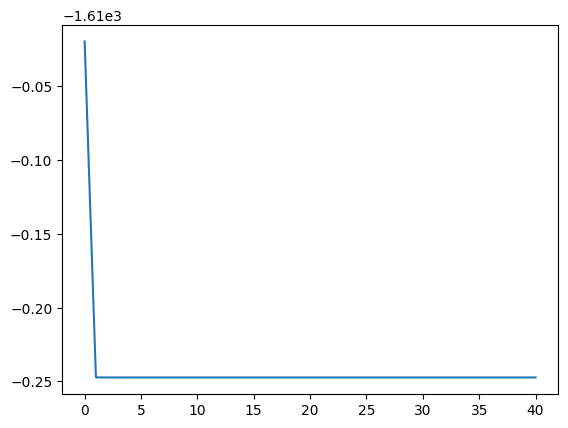

In [11]:
plt.plot(mycebmf.obj)

tensor(0.0198, dtype=torch.float64)

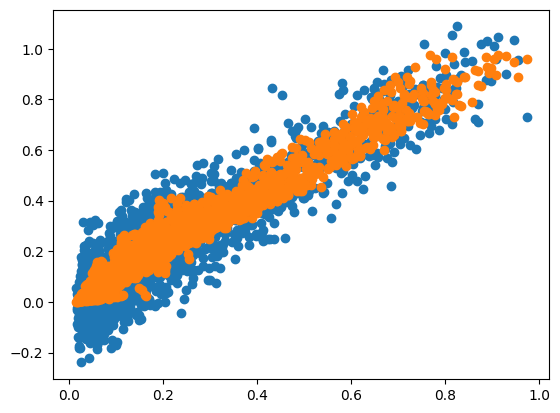

In [12]:
plt.scatter(mycebmf.Y_fit, noisy_matrix)
 
plt.scatter(mycebmf.Y_fit, rank_1_matrix)
torch.sqrt(torch.mean(mycebmf.Y_fit- rank_1_matrix)**2)

In [13]:
results =[]
for i in range(100):
    # Parameters
    n, p = 50, 40
    noise_std = 0.1

# (Optional) choose device
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ---- Data generation (PyTorch)
# Use float64 to mirror NumPy defaults
    u = torch.rand(n, dtype=torch.float64, device=device)          # length n
    v = torch.rand(p, dtype=torch.float64, device=device)          # length p

# Rank-1 matrix via outer product
    rank_1_matrix = torch.outer(u, v)                              # (n, p)

# Homoscedastic Gaussian noise
    noise = noise_std * torch.randn(n, p, dtype=torch.float64, device=device)

    noisy_matrix = rank_1_matrix + noise

 
# Add homoscedastic Gaussian noise (constant variance across the matrix)
    mycebmf=  cEBMF(data= noisy_matrix, prior_F="exp", prior_L="exp") 
    mycebmf.initialise_factors()
    mycebmf.fit()
    
    mycebmf._update_fitted_value()
    
    rr = torch.sqrt(torch.mean(mycebmf.Y_fit- rank_1_matrix)**2)
    results.append( rr)
    results.append( rr)
    res= np.asarray(results)
    print(np.mean(res ))
 

0.0012198739224803799
0.0006577050607624216
0.00057237923826872
0.0006373289702738664
0.0009631458221488068
0.0009102065876469867
0.001073047815976665
0.0010476764511537326
0.0012229914729926644
0.001122146863161689
0.0012694301556416578
0.0013416123757531376
0.001401172904714448
0.0014447411398560755
0.001707599703027523
0.0016267342357723733
0.0017130418874730532
0.0016776761123913665
0.0017599542334624477
0.0017196610625767363
0.0017147464028810914
0.0017069925499983763
0.0017844001629461071
0.0017842154601672461
0.0019199358210432271
0.002022324306878338
0.0020734525616945775
0.002011871121902321
0.0019431417062507016
0.0019391267833400337
0.0019568754799553275
0.001986700494617615
0.0019571379922744894
0.0021293981790498646
0.002196298445904677
0.002239736100049813
0.002203959239672346
0.0021604959101345204
0.0021267896214280423
0.0021009738614379838
0.002076355400386799
0.002027368776472339
0.002010511040569624
0.0020532822305945816
0.0020092570352927153
0.001968057502087998
0.00

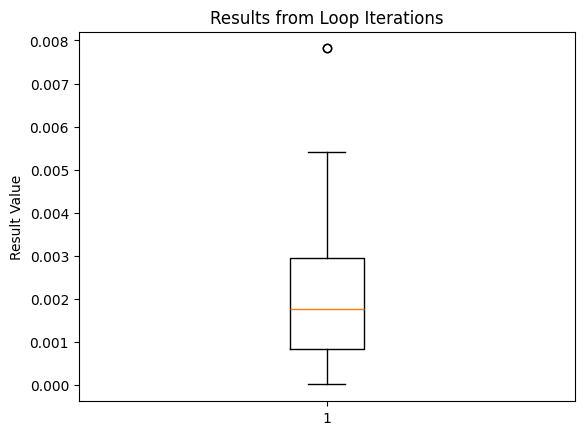

In [14]:
plt.boxplot(results)
plt.title("Results from Loop Iterations")
plt.ylabel("Result Value")
plt.show()

In [15]:
res= np.asarray(results)
np.mean(res )

np.float64(0.0020086610466037683)

In [16]:
np.sqrt(np.var(res ))

np.float64(0.0015484290643530728)

In [ ]:
0.1474302336345511

0.1474302336345511

: 